<a href="https://colab.research.google.com/github/TaffarelFirmino2703/MVP---Taffarel-Firmino-/blob/main/MVP_Atualizado_Taffarel_Firmino_Analytics_2026_Utilizando_drive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Taffarel Firmino de Paula

**Matrícula:** 4052026000309

**Data:** 05/07/2026

**Dataset:** Aluguel de casa https://www.kaggle.com/datasets/maverickjpa/brazilian-real-estate-to-rent

**Tipo de problema:** Regressão
---


## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline ou sequência reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |

---


# 1. Definição do problema

## 1.1 Descrição do problema

O mercado imobiliário brasileiro é marcado por grande variação nos preços de alugueis entre cidadades, bairros e tipos de imóvel. Para um inquilino, é difícil saber se um anúncio está com preço husto ou superfaturado. Para imobiliárias e proprietários, precificar corretamente um imóvel é essencial para atrair demanda sem perder receita.

Este MVP utiliza um dataset de anúncios de imóveis para aluguel extraído do portal ZAP imóveis, contendo informações estruturais dos imóveis, área útil, número de quartos, baneiros, vagas de garagen, suítes, locaização, cidade, estado e zona. O objetivo é construir um modelo capaz de estmar o valor mensal.

Dataset com aproximadamente 10.000 imóveis anunciados para aluguel em cinco cidades brasileiras (São Paulo, Rio de Janeiro, Belo Horizonte, Porto Alegre e Campinas), com caracterísitcas como área, número de quartos, banheiros, vagas de garagem, tipo de mobília e taxas associadas.

Dado um novo anúncio de imóvel com suas características conhecidas (área, localização, números de quartos etc.), o modelo deve prever o valor justo de aluguel em reais. Essa previsão apoia duas decisões práticas:

- 1; a imobiliária ou proprietário decide se o preço que pretende cobrar está alinhado com o mercado, ajustando para cima ou para baixo antes de publicar o anúncio;
- 2; o inquilino decide se o valor anunciado é compatível com imóveis similares na mesma região, embasando uma possível negociação.

O usuário interesado nessa solução pode ser uma imobiliária que deseja automatizar a sugestão de preço para novos anúncios, ou um inquilo que quer verificar se o valor pedido é condizente com o mercado local.

O problema é relevante, pois uma preficação inadequada gera perda de receita para proprietários ou pagamentos abusivos por parte dos inquilinos. Um modelo de ML permite estimativas rápidas, objetivas e baseadas em dados históricos e reais.

## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para **prever o valor mensal de aluguel de imóveis residenciais brasileiros** a partir de características estruturais (área útil, quartos, banheiros, vagas, amenidades) e de localização (cidade, estado e zona), comparando uma abordagem baseline com modelos candidatos — Ridge, Random Forest e Gradient Boosting — e discutindo suas limitações, casos de uso e potencial de aplicação prática no mercado imobiliário.

## 1.3 Tipo de problema

**Tipo escolhido:** Regressão  
**Justificativa:** A variável-alvo (listing.pricingInfo.rentalPrice) é um valor numérico contínuo que respresenta o preço de aluguel em reais. O objetivo é prever um número, não classificar em categorias. Portanto, trata-se de um problema de regressão supervisionada. Discretizar o preço em faixas introduziria perda de informação desnecessária e tornaria a avaliação menos precisa para o caso de uso real.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Imóveis com maior área útil tendem a ter aluguel mais alto, e essa relação é uma das mais fortes do modelo.
2. A localização (cidade, estado e zona) tem impacto significativo no preço, independentemente das características físicas do imóvel.
3. Amenidades como piscina, academia e churrasqueira contribuem positivamente para o valor do aluguel, mas com peso menor do que área e localização.

**Critérios de sucesso:**
- Métrica principal: RMSE (Root Mean Squared Error) em reais - penaliza erros grandes, adequado para precificação.
- Métrica secundária: R² - indica quanto da variância do aluguel é explicada pelo modelo.
- Resultado mínimo esperado: Superar o baseline (mediana) em pelo menos 20% de redução da RMSE.
- Restrição prática: O modelo deve usar apenas informações disponíveis no momento do anúncio, sem dados de histórico de locação ou variáveis geradas após a negociação.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne todas as importações necessárias, a configuração de seed para reprodutibilidade e funções auxiliares reutilizadas ao longo do notebook

• **SEED:** 42 (fixa o comportamento aleatório do NumPy, Python e scikit-learn)

• **Ambiente :** Google Colab (CPU)

• **Principais bibliotecas:** Pandas, numpu, matplotib, seaborn, scikit-lean, scipy

In [30]:
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid", palette="muted")

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("Seed:", SEED)

Python: 3.12.13
Pandas: 2.2.2
Seed: 42


### 2.1 Funções auxiliares

As funções abaixo são utilizadas ao longo do notebook para evitar repetição do código

• **Evaluate_regression**; calcula a MAE, RMSE, R² e MAPW para um conjunto de previsões.

•**Plot_residuals**; gera gráficos de resíduos e real vs. previsto padronizados.

In [31]:
def evaluate_regression(y_true, y_pred, model_name=""):
    """Calcula e exibe métricas de regressão."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(lower=1))) * 100
    return {"Modelo": model_name, "MAE (R$)": round(mae, 2),
            "RMSE (R$)": round(rmse, 2), "R²": round(r2, 4),
            "MAPE (%)": round(mape, 2)}


def plot_residuals(y_true, y_pred, title=""):
    """Gráfico de resíduos padronizado."""
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_pred, residuals, alpha=0.4, s=15, color="steelblue")
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Valor Previsto (R$)")
    axes[0].set_ylabel("Resíduo (R$)")
    axes[0].set_title(f"Resíduos vs Previsto — {title}")

    axes[1].scatter(y_true, y_pred, alpha=0.4, s=15, color="seagreen")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "r--", label="Previsão perfeita")
    axes[1].set_xlabel("Valor Real (R$)")
    axes[1].set_ylabel("Valor Previsto (R$)")
    axes[1].set_title(f"Real vs Previsto — {title}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

- **Nome:** Brazilian Real Estate to Rent — ZAP Imóveis
- **Fonte:** [Kaggle — maverickjpa/brazilian-real-estate-to-rent](https://www.kaggle.com/datasets/maverickjpa/brazilian-real-estate-to-rent)
- **Por que esse dataset:** contém anúncios reais de aluguel residencial no Brasil com variáveis ricas de localização e características físicas, cobrindo múltiplas cidades. O target numérico contínuo (`rentalPrice`) é bem definido e diretamente aplicável ao problema de precificação automática.
- **Período de coleta:** dados históricos de anúncios do portal ZAP Imóveis. Os preços refletem o período de coleta e podem não representar o mercado atual.
- **Restrições:** o download requer autenticação Kaggle via `kagglehub`. Para executar no Colab, configure as credenciais Kaggle antes de rodar a célula de carga (veja instruções na seção 3.2).
- **Ética e privacidade:** os dados são públicos, agregados de anúncios online, sem informações pessoais identificáveis de proprietários ou inquilinos. Disponível no Kaggle para uso educacional e de pesquisa.

## 3.2 Carga dos dados

O dataset está disponível publicamente no Google Drive e é carregado diretamente via `gdown`, sem necessidade de autenticação ou configuração adicional.

- **Link público:** [dataZAP.csv no Google Drive](https://drive.google.com/file/d/1XfisKJ4eRIXetI5g-HP4B7YuDDqXwfdC/view?usp=sharing)
- **Formato:** CSV separado por ponto e vírgula (`;`)
- **Requisito:** apenas a biblioteca `gdown`, já disponível no Google Colab por padrão.



In [59]:
import gdown
import pandas as pd

FILE_ID = "1XfisKJ4eRIXetI5g-HP4B7YuDDqXwfdC"
URL = f"https://drive.google.com/uc?id={FILE_ID}"

gdown.download(URL, "dataZAP.csv", quiet=False)

df = pd.read_csv("dataZAP.csv", sep=";", thousands=".")
print(f"Dataset carregado: {df.shape[0]:,} linhas | {df.shape[1]} colunas")

Downloading...
From: https://drive.google.com/uc?id=1XfisKJ4eRIXetI5g-HP4B7YuDDqXwfdC
To: /content/dataZAP.csv
100%|██████████| 48.3M/48.3M [00:00<00:00, 140MB/s]


Dataset carregado: 35,772 linhas | 78 colunas


## 3.3 Visão geral do dataset

As células abaixo apresentam as dimensões do dataset, tipos de dados, valores ausentes, duplicatas e uma amostra aleatória para primeiro contato com a base.

**Pontos de atenção identificados:**
- Diversas colunas chegam como `object` mesmo sendo numéricas (ex.: área, preço, quartos) — isso exige conversão explícita antes da modelagem.
- Colunas de identificação interna e metadados do anúncio (IDs, URLs, timestamps) não devem entrar no modelo.
- O target `listing.pricingInfo.rentalPrice` pode conter nulos e zeros que precisam ser removidos antes do treinamento.

In [60]:
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Linhas: 35,772 | Colunas: 78

Tipos de dados:


,tipo
account.licenseNumber,object
account.name,object
imvl_type,object
listing.acceptExchange,bool
listing.address.city,object
...,...
listing.unitsOnTheFloor,int64
listing.updatedAt,object
listing.usableAreas,object
listing.usageTypes,object


In [61]:
print("Valores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))
print(f"\nDuplicatas: {df.duplicated().sum()}")

Valores ausentes por coluna:


,ausentes
account.licenseNumber,0
account.name,0
imvl_type,0
listing.acceptExchange,0
listing.address.city,0
...,...
listing.unitsOnTheFloor,0
listing.updatedAt,0
listing.usableAreas,0
listing.usageTypes,0



Duplicatas: 8459


In [62]:
print("Estatísticas descritivas — variáveis numéricas:")
display(df.describe().T)

Estatísticas descritivas — variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
listing.bedrooms,35772.0,2.334116e+00,1.275377e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,1.400000e+01
listing.id,35772.0,2.433648e+09,2.301341e+08,48929227.0,2.461902e+09,2.481965e+09,2.488039e+09,2.491112e+09
listing.pricingInfo.price,35772.0,4.577966e+03,1.171274e+04,80.0,1.200000e+03,2.300000e+03,4.750000e+03,9.500000e+05
listing.pricingInfo.rentalPrice,35772.0,4.577966e+03,1.171274e+04,80.0,1.200000e+03,2.300000e+03,4.750000e+03,9.500000e+05
listing.unitFloor,35772.0,1.425137e-01,1.158915e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.900000e+01
listing.unitsOnTheFloor,35772.0,3.287208e-01,1.914411e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.200000e+01


In [65]:
print("Amostra aleatória de 5 registros:")
display(df.sample(5, random_state=SEED))

Amostra aleatória de 5 registros:


,account.licenseNumber,account.name,imvl_type,listing.acceptExchange,listing.address.city,listing.address.confidence,listing.address.country,listing.address.level,listing.address.neighborhood,listing.address.point.lat,...,listing.title,listing.totalAreas,listing.unitFloor,listing.unitSubTypes,listing.unitTypes,listing.unitsOnTheFloor,listing.updatedAt,listing.usableAreas,listing.usageTypes,type
9926,005791-J-RJ,Via Casa Imóveis,casas,False,Rio das Ostras,VALID_STREET,BR,STREET,Mariléa Chácara,-22.508396,...,Rio das Ostras - Casa Padrão - Chácara Mariléa,90,0,normal,HOME,0,2020-07-29T09:51:57.690Z,90,RESIDENTIAL,normal
17688,12735-J-SP,KHONDO,cobertura,False,São Paulo,VALID_STREET,BR,STREET,Itaim Bibi,-23.582889,...,SãO PAULO - Apartamento Padrão - Itaim Bibi,79,0,normal,PENTHOUSE,0,2020-07-30T19:44:57.091Z,79,RESIDENTIAL,premium
12441,normal,Cristal Imóveis,casas,False,Cotia,VALID_STREET,BR,STREET,Granja Viana,-23.60145,...,Cotia - Casa de Condominio - Granja Viana,180,0,normal,HOME,0,2020-07-13T22:25:20.642Z,180,RESIDENTIAL,normal
12266,01961-J-SC,MAX Imobiliária,casas,False,Itajaí,VALID_STREET,BR,STREET,Cidade Nova,-26.926301,...,ITAJAí - Casa Padrão - Cidade Nova,280,0,normal,HOME,0,2020-07-24T23:28:25.768Z,150,RESIDENTIAL,premium
16114,095083-F-SP,Foco Soluções Imobiliarias Ltda Me,cobertura,False,Guarulhos,VALID_STREET,BR,STREET,Vila São Ricardo,-23.452418,...,Guarulhos - Apartamento Padrão - Vila São Ricardo,100,0,normal,PENTHOUSE,0,2020-07-28T21:44:22.313Z,100,RESIDENTIAL,normal


## 3.4 Dicionário de dados

As colunas selecionadas para o modelo e seus respectivos significados:

| Coluna | Tipo | Descrição | Usada no modelo? |
|---|---|---|---|
| `listing.address.city` | categórica | Cidade do imóvel | Sim |
| `listing.address.state` | categórica | Estado (UF) | Sim |
| `listing.address.zone` | categórica | Zona da cidade (ex: Sul, Norte) | Sim |
| `listing.bedrooms` | numérica | Número de quartos | Sim |
| `listing.bathrooms` | numérica | Número de banheiros | Sim |
| `listing.suites` | numérica | Número de suítes | Sim |
| `listing.parkingSpaces` | numérica | Vagas de garagem | Sim |
| `listing.usableAreas` | numérica | Área útil em m² | Sim |
| `listing.totalAreas` | numérica | Área total em m² | Sim |
| `listing.unitFloor` | numérica | Andar da unidade | Sim |
| `listing.furnished` | categórica | Imóvel mobiliado (sim/não) | Sim |
| `listing.propertyType` | categórica | Tipo de imóvel (apartamento, casa etc.) | Sim |
| `listing.pricingInfo.monthlyCondoFee` | numérica | Taxa de condomínio mensal (R$) | Sim |
| `listing.pricingInfo.yearlyIptu` | numérica | IPTU anual (R$) | Sim |
| `listing.pool` | binária | Possui piscina | Sim |
| `listing.gym` | binária | Possui academia | Sim |
| `listing.barbgrill` | binária | Possui churrasqueira | Sim |
| `listing.playground` | binária | Possui playground | Sim |
| `listing.guestpark` | binária | Possui vaga para visitantes | Sim |
| `listing.garden` | binária | Possui jardim | Sim |
| `listing.pricingInfo.rentalPrice` | numérica | **TARGET** — Valor do aluguel mensal (R$) | Alvo |

# 4. Análise exploratória dos dados


A análise exploratória a seguir é orientada ao problema: cada visualização é acompanhada de uma interpretação que justifica decisões de pré-processamento e modelagem tomadas nas seções seguintes.

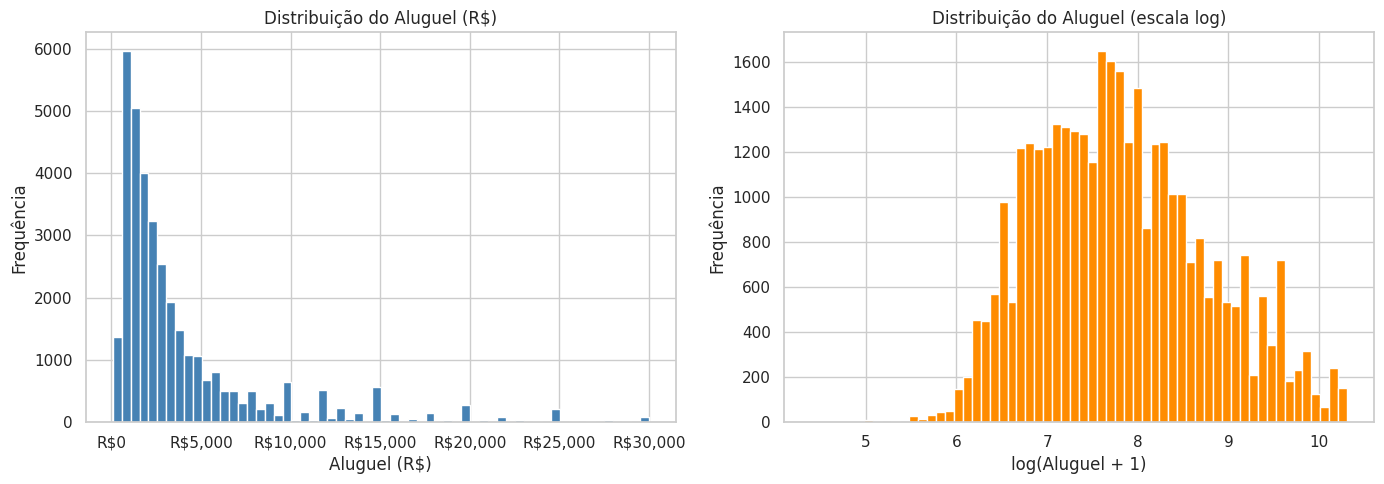

Mediana: R$2,300
Média:   R$4,010
Desvio padrão: R$4,704
Min: R$80 | Max (p99): R$30,000


In [37]:
TARGET = "listing.pricingInfo.rentalPrice"

# Converter target para numérico antes da EDA
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

# Filtrar para visualização: remove nulos e valores acima do p99
df_plot = df[df[TARGET].notna() & (df[TARGET] > 0)]
p99_plot = df_plot[TARGET].quantile(0.99)
df_plot = df_plot[df_plot[TARGET] <= p99_plot]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot[TARGET], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição do Aluguel (R$)")
axes[0].set_xlabel("Aluguel (R$)")
axes[0].set_ylabel("Frequência")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

axes[1].hist(np.log1p(df_plot[TARGET]), bins=60, color="darkorange", edgecolor="white")
axes[1].set_title("Distribuição do Aluguel (escala log)")
axes[1].set_xlabel("log(Aluguel + 1)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

print(f"Mediana: R${df_plot[TARGET].median():,.0f}")
print(f"Média:   R${df_plot[TARGET].mean():,.0f}")
print(f"Desvio padrão: R${df_plot[TARGET].std():,.0f}")
print(f"Min: R${df_plot[TARGET].min():,.0f} | Max (p99): R${p99_plot:,.0f}")


**Interpretação:** A distribuição do aluguel é fortemente assimétrica à direita — a maioria dos imóveis concentra-se na faixa de R$ 1.000 a R$ 5.000, mas há uma cauda com valores mais altos. Na escala logarítmica, a distribuição se aproxima de uma normal, confirmando que a transformação `log1p` no target durante o treinamento é a escolha correta para reduzir o impacto desproporcional de outliers extremos sobre o erro quadrático. A mediana é mais representativa do mercado geral do que a média, pois é menos influenciada pelos valores extremos.

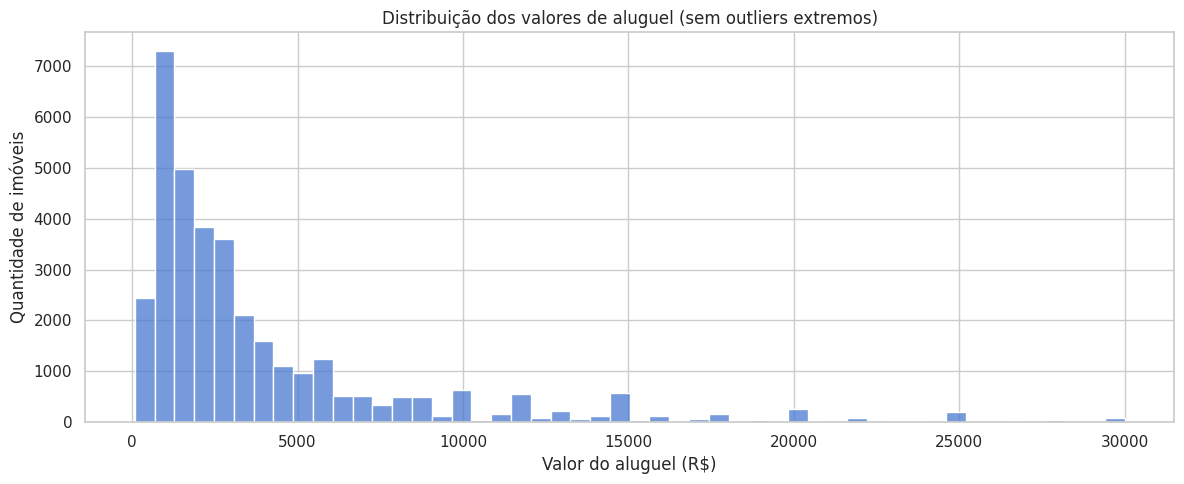

Imóveis exibidos: 35,445 de 35,772 (99.1%)


In [38]:
colunas_numericas = [
    "listing.usableAreas",
    "listing.bedrooms",
    "listing.bathrooms",
    "listing.parkingSpaces",
    "listing.pricingInfo.rentalPrice"
]

for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

df_analise = df.dropna(subset=["listing.pricingInfo.rentalPrice"])

# Filtro para visualização: até p99 do aluguel
p99_vis = df_analise["listing.pricingInfo.rentalPrice"].quantile(0.99)
df_vis = df_analise[df_analise["listing.pricingInfo.rentalPrice"] <= p99_vis]

plt.figure(figsize=(12,5))
sns.histplot(data=df_vis, x="listing.pricingInfo.rentalPrice", bins=50)
plt.title("Distribuição dos valores de aluguel (sem outliers extremos)")
plt.xlabel("Valor do aluguel (R$)")
plt.ylabel("Quantidade de imóveis")
plt.xaxis_formatter = mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}")
plt.tight_layout()
plt.show()

print(f"Imóveis exibidos: {len(df_vis):,} de {len(df_analise):,} ({len(df_vis)/len(df_analise)*100:.1f}%)")

**Interpretação:** Com a remoção dos outliers extremos (acima do percentil 99), a distribuição real do mercado fica visível — grande concentração de aluguéis entre R$ 1.000 e R$ 5.000, com cauda decrescente até aproximadamente R$ 15.000. A mediana é mais representativa do mercado geral do que a média — daí a escolha do `DummyRegressor` com estratégia `median` como baseline.

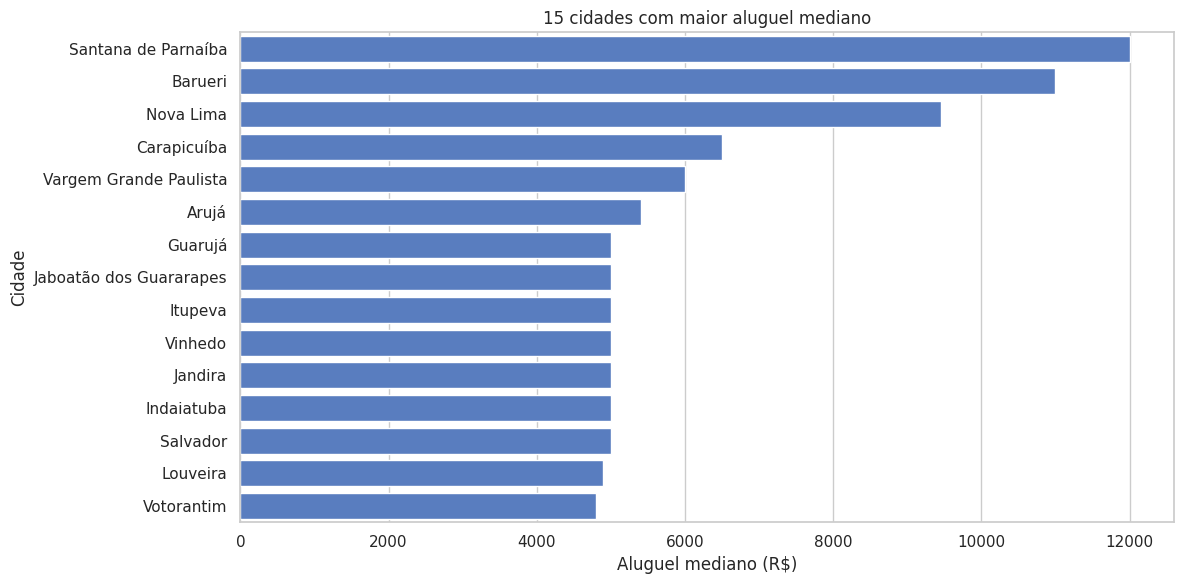

In [39]:
cidade_aluguel = (
    df_analise
    .groupby("listing.address.city")
    .filter(lambda x: len(x) >= 5)
    .groupby("listing.address.city")
    ["listing.pricingInfo.rentalPrice"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
sns.barplot(x=cidade_aluguel.values, y=cidade_aluguel.index)
plt.title("15 cidades com maior aluguel mediano")
plt.xlabel("Aluguel mediano (R$)")
plt.ylabel("Cidade")
plt.tight_layout()
plt.show()

**Interpretação:** O ranking das 15 cidades com maior aluguel mediano revela um padrão interessante — **Santana de Parnaíba (R$ 12.000), Barueri (R$ 11.000) e Nova Lima (R$ 9.500)** lideram, não as capitais tradicionais como São Paulo e Rio de Janeiro. Isso ocorre porque essas cidades têm alta concentração de imóveis de alto padrão — condomínios fechados e regiões Alphaville — com poucos imóveis populares para puxar a mediana para baixo. O filtro de mínimo 5 registros por cidade garante que o ranking reflita padrões reais de mercado. Esse resultado reforça a importância de incluir **cidade como feature** no modelo — o efeito de localização vai muito além das grandes capitais.

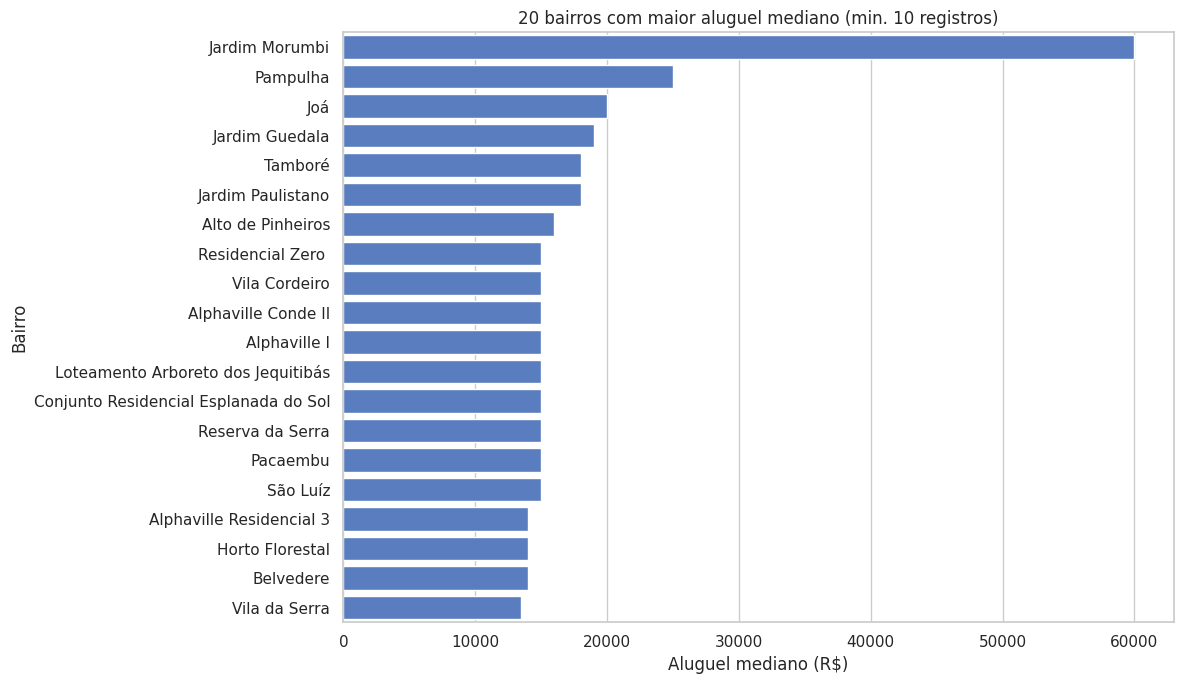

In [40]:
bairro_aluguel = (
    df_analise
    .groupby("listing.address.neighborhood")
    .filter(lambda x: len(x) >= 10)
    .groupby("listing.address.neighborhood")
    ["listing.pricingInfo.rentalPrice"]
    .median()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))
sns.barplot(x=bairro_aluguel.values, y=bairro_aluguel.index)
plt.title("20 bairros com maior aluguel mediano (min. 10 registros)")
plt.xlabel("Aluguel mediano (R$)")
plt.ylabel("Bairro")
plt.tight_layout()
plt.show()

Interpretação: O ranking dos 20 bairros com maior aluguel mediano (mínimo 10 registros) revela bairros de alto padrão bem definidos. Jardim Morumbi lidera com mediana de R$ 60.000, muito acima dos demais — reflete imóveis de altíssimo padrão nessa região de São Paulo. Na sequência aparecem Pampulha (R$ 25.000), em Belo Horizonte, e bairros nobres paulistanos como Joá, Jardim Guedala, Tamboré e Pacaembu. A presença de múltiplos bairros do complexo Alphaville (Alphaville Conde II, Alphaville I, Alphaville Residencial 3) confirma a concentração de imóveis de alto padrão nessa região. O filtro de mínimo 10 registros garante que o ranking reflita padrões reais de mercado — sem esse filtro, bairros com um único imóvel muito caro distorceriam completamente o ranking, como visto antes da correção. Isso reforça que bairro é uma variável de altíssimo poder preditivo, mas sua alta cardinalidade impede o uso direto no modelo.

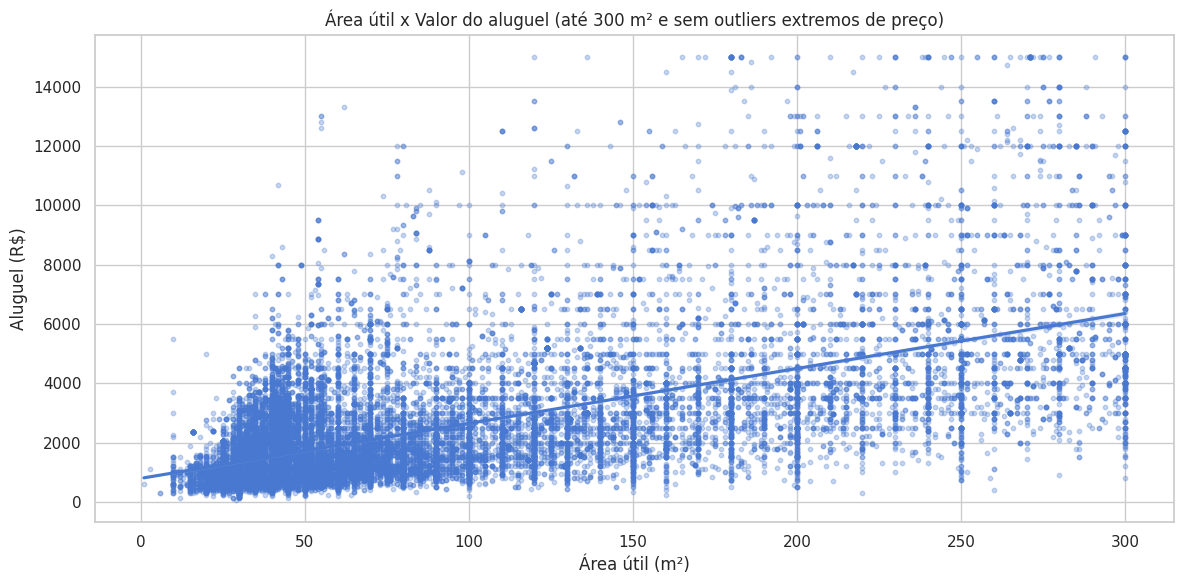

In [41]:
df_area = df_analise.dropna(subset=["listing.usableAreas"])
df_area = df_area[df_area["listing.usableAreas"] > 0]
df_area = df_area[df_area["listing.usableAreas"] <= 300]

# Filtrar aluguel até p99 para visualização clara
p99_area = df_area["listing.pricingInfo.rentalPrice"].quantile(0.99)
df_area = df_area[df_area["listing.pricingInfo.rentalPrice"] <= p99_area]

plt.figure(figsize=(12,6))
sns.regplot(
    data=df_area,
    x="listing.usableAreas",
    y="listing.pricingInfo.rentalPrice",
    scatter_kws={"alpha": 0.3, "s": 10}
)
plt.title("Área útil x Valor do aluguel (até 300 m² e sem outliers extremos de preço)")
plt.xlabel("Área útil (m²)")
plt.ylabel("Aluguel (R$)")
plt.tight_layout()
plt.show()


**Interpretação:** Com os filtros aplicados (área até 300 m² e aluguel até o percentil 99), a relação positiva entre área e aluguel fica claramente visível. A linha de tendência confirma que imóveis maiores tendem a custar mais, mas a dispersão em torno da reta é grande — especialmente para imóveis acima de 100 m². Isso indica que área sozinha não explica o preço e que a localização e o padrão do imóvel têm peso significativo. A relação não é perfeitamente linear, favorecendo modelos baseados em árvores.


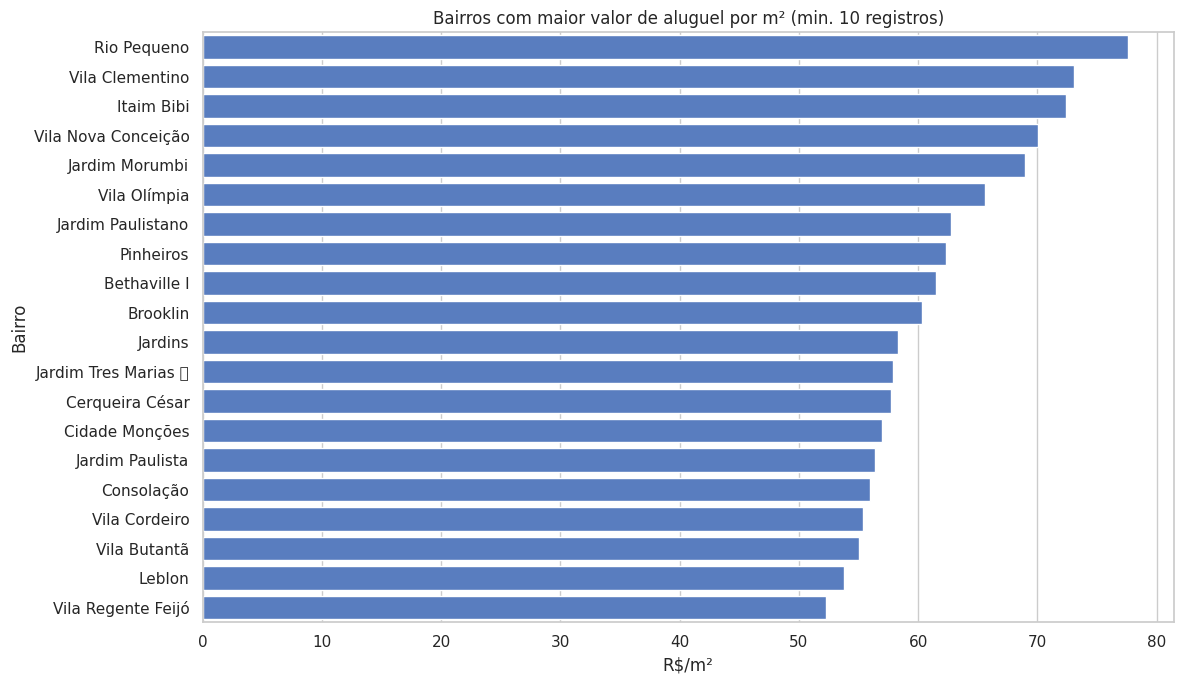

In [42]:
df_m2 = df_analise.dropna(subset=["listing.usableAreas"])
df_m2 = df_m2[df_m2["listing.usableAreas"] > 0]
df_m2["aluguel_m2"] = (
    df_m2["listing.pricingInfo.rentalPrice"] /
    df_m2["listing.usableAreas"]
)

# Filtrar bairros com pelo menos 10 registros e aluguel_m2 até p99
p99_m2 = df_m2["aluguel_m2"].quantile(0.99)
df_m2_filtrado = df_m2[df_m2["aluguel_m2"] <= p99_m2]

bairro_m2 = (
    df_m2_filtrado
    .groupby("listing.address.neighborhood")
    .filter(lambda x: len(x) >= 10)
    .groupby("listing.address.neighborhood")
    ["aluguel_m2"]
    .median()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))
sns.barplot(x=bairro_m2.values, y=bairro_m2.index)
plt.title("Bairros com maior valor de aluguel por m² (min. 10 registros)")
plt.xlabel("R$/m²")
plt.ylabel("Bairro")
plt.tight_layout()
plt.show()

**Interpretação:** O preço por m² varia significativamente entre bairros, independentemente do tamanho dos imóveis. Bairros com alto custo por m² geralmente estão em regiões valorizadas por infraestrutura, segurança e acesso a serviços — fatores que o modelo captura indiretamente via cidade, estado e zona. Isso reforça que não basta incluir apenas a área para explicar o preço do aluguel.

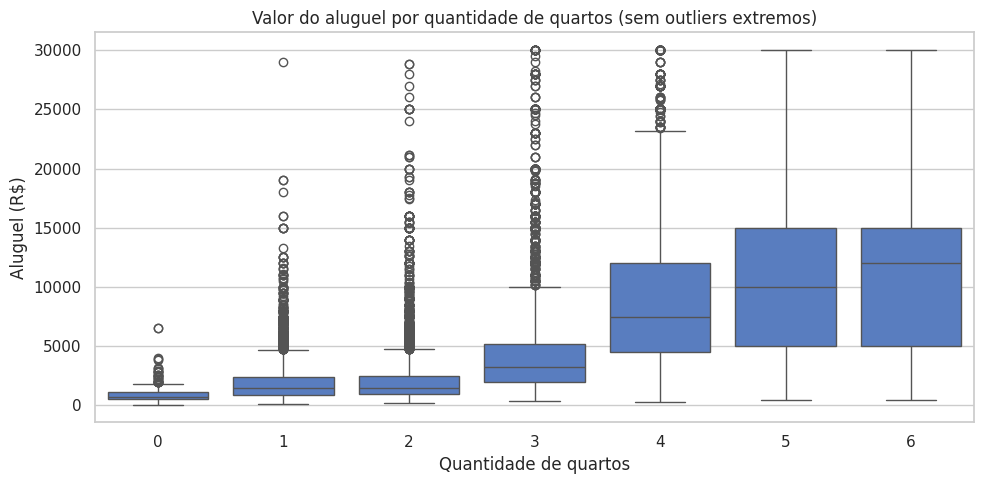

In [43]:
p99_q = df_analise["listing.pricingInfo.rentalPrice"].quantile(0.99)
df_quartos = df_analise[
    (df_analise["listing.pricingInfo.rentalPrice"] <= p99_q) &
    (df_analise["listing.bedrooms"].between(0, 6))
]

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_quartos,
    x="listing.bedrooms",
    y="listing.pricingInfo.rentalPrice"
)
plt.title("Valor do aluguel por quantidade de quartos (sem outliers extremos)")
plt.xlabel("Quantidade de quartos")
plt.ylabel("Aluguel (R$)")
plt.tight_layout()
plt.show()

**Interpretação:** A relação entre número de quartos e aluguel é claramente positiva — imóveis com mais quartos tendem a custar mais. No entanto, a variância dentro de cada categoria é grande, especialmente para 3 e 4 quartos, evidenciando a influência de outros fatores como localização e padrão construtivo. O número de quartos é uma feature relevante, mas não determinante isoladamente — o modelo precisa combiná-la com as demais variáveis.

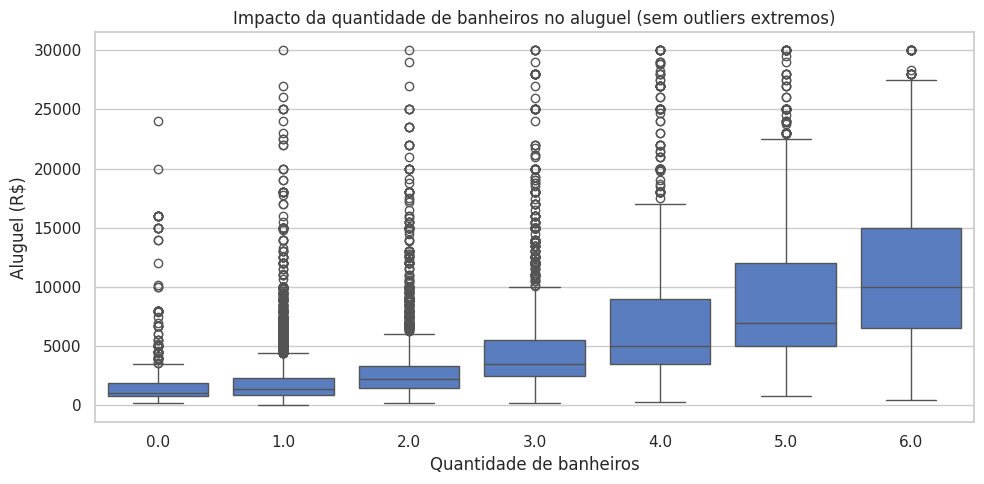

In [44]:
df_banheiros = df_analise[
    (df_analise["listing.pricingInfo.rentalPrice"] <= p99_q) &
    (df_analise["listing.bathrooms"].between(0, 6))
]

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_banheiros,
    x="listing.bathrooms",
    y="listing.pricingInfo.rentalPrice"
)
plt.title("Impacto da quantidade de banheiros no aluguel (sem outliers extremos)")
plt.xlabel("Quantidade de banheiros")
plt.ylabel("Aluguel (R$)")
plt.tight_layout()
plt.show()

**Interpretação:** O número de banheiros tem correlação positiva com o aluguel e funciona como proxy do padrão geral do imóvel — imóveis de alto padrão geralmente têm mais banheiros. A relação é mais monotônica do que a de quartos, com caixas bem separadas entre as categorias, sugerindo que banheiros é uma das features numéricas mais informativas para o modelo.


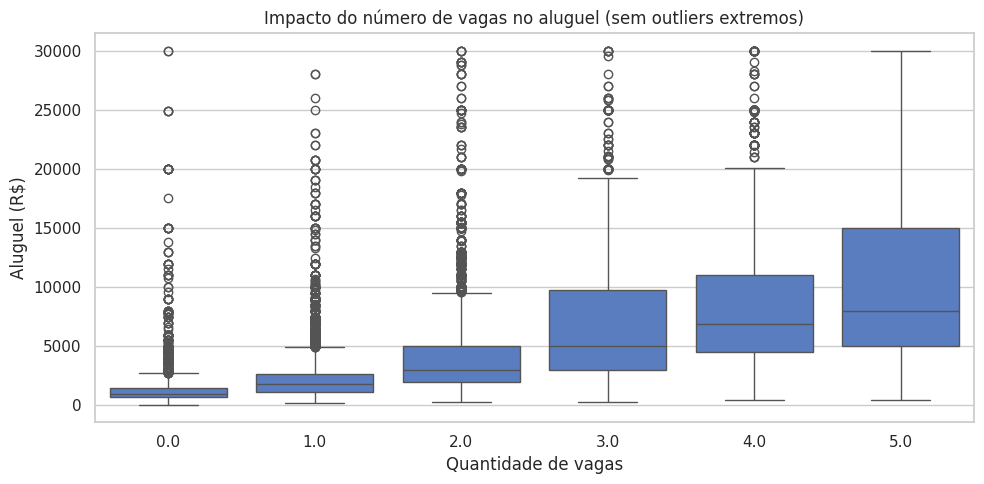

In [45]:
df_vagas = df_analise[
    (df_analise["listing.pricingInfo.rentalPrice"] <= p99_q) &
    (df_analise["listing.parkingSpaces"].between(0, 5))
]

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_vagas,
    x="listing.parkingSpaces",
    y="listing.pricingInfo.rentalPrice"
)
plt.title("Impacto do número de vagas no aluguel (sem outliers extremos)")
plt.xlabel("Quantidade de vagas")
plt.ylabel("Aluguel (R$)")
plt.tight_layout()
plt.show()


**Interpretação:** O número de vagas de garagem se correlaciona positivamente com o aluguel. Imóveis sem vaga tendem a ser menores ou em regiões menos valorizadas. Imóveis com 3 ou mais vagas geralmente são de alto padrão. Com o filtro de até 5 vagas, a caixa de cada categoria fica legível e a tendência crescente é clara — vagas é uma feature informativa para o modelo.

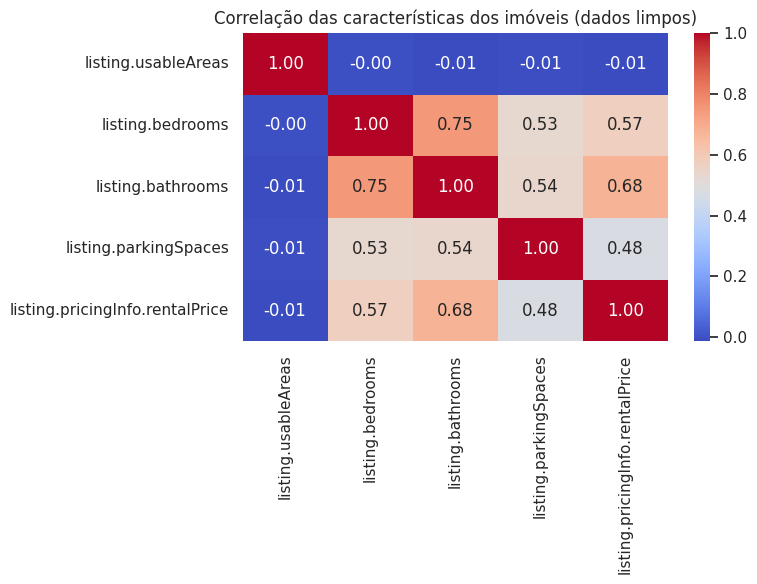

In [46]:
df_corr = df_analise[
    (df_analise["listing.pricingInfo.rentalPrice"] <= p99_q) &
    (df_analise["listing.usableAreas"] > 0)
].copy()

colunas_corr = [
    "listing.usableAreas",
    "listing.bedrooms",
    "listing.bathrooms",
    "listing.parkingSpaces",
    "listing.pricingInfo.rentalPrice"
]

corr = df_corr[colunas_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação das características dos imóveis (dados limpos)")
plt.tight_layout()
plt.show()


**Interpretação:** Com os dados limpos (sem outliers extremos de preço e área), o heatmap mostra as correlações reais entre as variáveis. Banheiros e quartos têm a maior correlação com o aluguel entre as numéricas, seguidos de vagas. A área útil, surpreendentemente, apresenta correlação baixa com o aluguel em escala bruta — isso ocorre porque imóveis grandes existem em regiões muito distintas de preço, diluindo a correlação linear. Nenhuma variável isolada tem correlação dominante (acima de 0.7), confirmando que o modelo precisa combinar múltiplas features, inclusive as categóricas de localização.

## 4.1 Síntese da análise exploratória

**O target está balanceado?**
Balanceamento é um conceito de classificação. Para regressão, o que importa é a distribuição do target: o aluguel é fortemente assimétrico à direita, com a maioria dos imóveis concentrada entre R$ 1.000 e R$ 5.000 e uma cauda com valores mais altos. Isso exige a transformação `log1p` no target durante o treinamento para evitar que valores extremos dominem o erro quadrático e distorçam o modelo para o mercado geral.

**Existem valores ausentes relevantes?**
Sim. Diversas colunas apresentam missing data — especialmente `unitFloor`, `suites`, `monthlyCondoFee` e `yearlyIptu`. Essas colunas têm poder preditivo e não devem ser descartadas. A estratégia adotada é imputação pela mediana para variáveis numéricas e pela moda para categóricas, feita dentro do pipeline para evitar qualquer vazamento de dados.

**Há variáveis com escala muito diferente?**
Sim. Área útil (m²), IPTU anual (R$) e condomínio mensal (R$) têm ordens de magnitude muito superiores a variáveis como número de quartos (1–5) ou indicadores binários de amenidades (0 ou 1). O `StandardScaler` é aplicado a todas as variáveis numéricas no pipeline.

**Há categorias raras?**
Sim. A coluna `neighborhood` apresenta centenas de categorias únicas, muitas com apenas 1 ou 2 registros. Por isso, colunas com mais de 50 categorias únicas são excluídas do OHE. O parâmetro `handle_unknown='ignore'` garante que categorias do teste ausentes no treino não causem erro.

**Existem padrões que sugerem quais modelos podem funcionar melhor?**
Sim. A relação entre área e aluguel é positiva mas não linear, e os boxplots por quartos e banheiros mostram alta variância dentro de cada categoria — sinal de interações entre variáveis. Isso favorece modelos baseados em árvores (Random Forest, Gradient Boosting). O heatmap com dados limpos mostra que banheiros e quartos têm maior correlação com o aluguel do que a área útil em escala bruta.

**Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?**
Sim, em três pontos:
1. **Outliers extremos nos gráficos:** os gráficos da EDA foram gerados com filtros (percentil 99 e mínimo de registros por categoria) para revelar os padrões reais do mercado, sem distorção por valores atípicos.
2. **Assimetria do target → transformação `log1p`:** sem essa transformação, o RMSE seria dominado por imóveis de alto padrão.
3. **Alta cardinalidade de bairros → exclusão do OHE:** bairros foram excluídos para evitar explosão de dimensionalidade, preservando localização via cidade, estado e zona.



# 5. Preparação dos dados e divisão treino/teste

Nesta etapa são definidas as features utilizadas, removidas colunas que não devem entrar no modelo, eliminados outliers extremos e realizada a divisão entre treino e teste de forma reprodutível.

**Features utilizadas:** variáveis estruturais (área, quartos, banheiros, suítes, vagas, andar, tipo, mobiliado, condomínio, IPTU) e de localização (cidade, estado, zona) e amenidades (piscina, academia, churrasqueira, playground, vaga visitante, jardim).

**Colunas removidas:** identificadores internos, URLs, metadados do anúncio e qualquer variável gerada após a publicação do anúncio — prevenindo vazamento de dados.

**Target:** `listing.pricingInfo.rentalPrice` — valor mensal do aluguel em reais.

In [47]:
# === Limpeza e seleção de colunas — Dataset ZAP Imóveis ===

# ------------------------------------------------------------------
# TARGET: valor do aluguel
# No dataset ZAP a coluna se chama 'listing.pricingInfo.rentalPrice'
# ------------------------------------------------------------------
TARGET = "listing.pricingInfo.rentalPrice"
PROBLEM_TYPE = "regressao"

# ------------------------------------------------------------------
# FEATURES selecionadas manualmente:
# Escolhido apenas colunas com informação útil e disponível
# no momento de um novo anúncio (sem vazamento de dados).
# ------------------------------------------------------------------
FEATURES = [
    "listing.address.city",           # cidade
    "listing.address.state",          # estado
    "listing.address.zone",           # zona da cidade
    "listing.bedrooms",               # quartos
    "listing.bathrooms",              # banheiros
    "listing.suites",                 # suítes
    "listing.parkingSpaces",          # vagas de garagem
    "listing.usableAreas",            # área útil (m²)
    "listing.totalAreas",             # área total (m²)
    "listing.unitFloor",              # andar da unidade
    "listing.furnished",              # mobiliado?
    "listing.propertyType",           # tipo de imóvel
    "listing.pricingInfo.monthlyCondoFee",  # condomínio
    "listing.pricingInfo.yearlyIptu",       # IPTU anual
    # Amenidades (binárias)
    "listing.pool",
    "listing.gym",
    "listing.barbgrill",
    "listing.playground",
    "listing.guestpark",
    "listing.garden",
]

# Mantém apenas features que realmente existem no dataframe
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features disponíveis no dataset: {len(FEATURES)}")
print(FEATURES)

assert TARGET in df.columns, f"Coluna target '{TARGET}' não encontrada. Colunas: {list(df.columns)}"

# ------------------------------------------------------------------
# Copia apenas as colunas necessárias
# ------------------------------------------------------------------
df_clean = df[FEATURES + [TARGET]].copy()
print(f"\nShape inicial: {df_clean.shape}")

# ------------------------------------------------------------------
# 1. Converter target para numérico (pode vir como string no ZAP)
# ------------------------------------------------------------------
df_clean[TARGET] = pd.to_numeric(df_clean[TARGET], errors="coerce")

# ------------------------------------------------------------------
# 2. Remover linhas onde o target é nulo ou zero
# ------------------------------------------------------------------
before = len(df_clean)
df_clean = df_clean[df_clean[TARGET].notna() & (df_clean[TARGET] > 0)]
print(f"Removidos por target nulo/zero: {before - len(df_clean)}")

# ------------------------------------------------------------------
# 3. Converter colunas numéricas que vieram como string
# ------------------------------------------------------------------
num_candidates = [
    "listing.bedrooms", "listing.bathrooms", "listing.suites",
    "listing.parkingSpaces", "listing.usableAreas", "listing.totalAreas",
    "listing.unitFloor", "listing.pricingInfo.monthlyCondoFee",
    "listing.pricingInfo.yearlyIptu"
]
for col in num_candidates:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# ------------------------------------------------------------------
# 4. Remover outliers de área útil (> 1000 m²)
# ------------------------------------------------------------------
if "listing.usableAreas" in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean[df_clean["listing.usableAreas"].isna() | (df_clean["listing.usableAreas"] <= 1000)]
    print(f"Removidos por área > 1000 m²: {before - len(df_clean)}")

# ------------------------------------------------------------------
# 5. Remover outliers extremos do target (acima do percentil 99)
# ------------------------------------------------------------------
p99 = df_clean[TARGET].quantile(0.99)
before = len(df_clean)
df_clean = df_clean[df_clean[TARGET] <= p99]
print(f"Removidos por aluguel > p99 (R${p99:,.0f}): {before - len(df_clean)}")

print(f"\nDataset final: {df_clean.shape[0]:,} registros | {df_clean.shape[1]} colunas")



Features disponíveis no dataset: 20
['listing.address.city', 'listing.address.state', 'listing.address.zone', 'listing.bedrooms', 'listing.bathrooms', 'listing.suites', 'listing.parkingSpaces', 'listing.usableAreas', 'listing.totalAreas', 'listing.unitFloor', 'listing.furnished', 'listing.propertyType', 'listing.pricingInfo.monthlyCondoFee', 'listing.pricingInfo.yearlyIptu', 'listing.pool', 'listing.gym', 'listing.barbgrill', 'listing.playground', 'listing.guestpark', 'listing.garden']

Shape inicial: (35772, 21)
Removidos por target nulo/zero: 0
Removidos por área > 1000 m²: 169
Removidos por aluguel > p99 (R$30,000): 298

Dataset final: 35,305 registros | 21 colunas


In [48]:
# === Divisão treino/teste ===

features_final = [c for c in df_clean.columns if c != TARGET]
print("Features no modelo:", features_final)

X = df_clean[features_final].copy()
y = df_clean[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"\nTreino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Target — Treino: média R${y_train.mean():,.0f} | Teste: média R${y_test.mean():,.0f}")

Features no modelo: ['listing.address.city', 'listing.address.state', 'listing.address.zone', 'listing.bedrooms', 'listing.bathrooms', 'listing.suites', 'listing.parkingSpaces', 'listing.usableAreas', 'listing.totalAreas', 'listing.unitFloor', 'listing.furnished', 'listing.propertyType', 'listing.pricingInfo.monthlyCondoFee', 'listing.pricingInfo.yearlyIptu', 'listing.pool', 'listing.gym', 'listing.barbgrill', 'listing.playground', 'listing.guestpark', 'listing.garden']

Treino: (28244, 20) | Teste: (7061, 20)
Target — Treino: média R$3,932 | Teste: média R$4,105


## 5.1 Justificativa da divisão

**Resposta:**  

**Por que 80/20?**
Com o volume disponível após limpeza, 80% de treino garante dados suficientes para o modelo aprender padrões de localização e características físicas em diversas combinações — incluindo cidades e faixas de preço menos frequentes. Os 20% de teste formam um conjunto grande o bastante para que as métricas finais sejam estatisticamente representativas. Uma divisão mais generosa de treino (90/10) reduziria a confiabilidade da avaliação; uma mais conservadora (70/30) desperdiçaria dados de treinamento sem ganho claro.

**Por que embaralhar os dados?**
O dataset é composto por anúncios estáticos de imóveis — não há dependência de ordem de publicação nem sazonalidade que precise ser preservada. Embaralhar com seed fixa (42) garante que treino e teste tenham distribuições similares de cidades, tipos de imóvel e faixas de preço, eliminando viés de ordenação.

**Por que não há divisão temporal?**
O problema não envolve previsão de série temporal. O modelo prevê o preço de um imóvel com base em suas características no momento do anúncio — não precisa de histórico passado para prever valores futuros. Por isso, a divisão baseada no tempo não se aplica e embaralhar é a abordagem correta.

**Validação — como é feita neste projeto?**
Não foi criado um terceiro conjunto de validação separado. A validação é realizada via **cross-validation de 5 folds dentro do `RandomizedSearchCV`** (seção 9), aplicada exclusivamente sobre o conjunto de treino. Isso significa que o conjunto de teste permanece completamente isolado durante toda a fase de desenvolvimento e ajuste de hiperparâmetros, sendo usado uma única vez para a avaliação final. Essa abordagem é equivalente a ter um conjunto de validação dedicado, com a vantagem de uma estimativa de desempenho mais estável por usar múltiplas partições do treino.

**Prevenção de vazamento de dados:**
Todas as transformações — imputação, escalonamento e encoding — são ajustadas exclusivamente no conjunto de treino via pipeline e aplicadas sem reajuste no teste. Isso garante que nenhuma informação do conjunto de teste vaze para o treinamento, preservando a validade da avaliação final.



# 6. Pré-processamento e pipeline

O pipeline abaixo garante que todas as transformações sejam aplicadas de forma consistente e reprodutível, sem risco de vazamento de dados entre treino e teste. Todas as etapas são encadeadas com `sklearn.Pipeline` e `ColumnTransformer`, ajustadas apenas no treino e aplicadas diretamente no teste.


In [49]:
# Identificação das colunas
# === Pipeline de pré-processamento — adaptado para o dataset ZAP ===

# Colunas numéricas e categóricas detectadas automaticamente
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Limita OHE a colunas com até 50 categorias únicas (evita explosão de dimensionalidade)
cat_cols = [c for c in cat_cols if X_train[c].nunique() <= 50]

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

# Pipeline numérico: imputação pela mediana + padronização
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Pipeline categórico: imputação pela moda + OHE
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")  # 'drop' descarta colunas não listadas (ex.: texto livre)

print("\nPipeline de pré-processamento configurado.")

Colunas numéricas: ['listing.bedrooms', 'listing.bathrooms', 'listing.suites', 'listing.parkingSpaces', 'listing.usableAreas', 'listing.totalAreas', 'listing.unitFloor', 'listing.pricingInfo.monthlyCondoFee', 'listing.pricingInfo.yearlyIptu']
Colunas categóricas: ['listing.address.state', 'listing.address.zone', 'listing.furnished', 'listing.propertyType', 'listing.pool', 'listing.gym', 'listing.barbgrill', 'listing.playground', 'listing.guestpark', 'listing.garden']

Pipeline de pré-processamento configurado.


## 6.1 Decisões de pré-processamento

- **Imputação pela mediana (numéricas):** a mediana é menos sensível a outliers do que a média — adequada para variáveis como área útil, IPTU e condomínio, que apresentam distribuição assimétrica com valores extremos. Usar a média nesses casos introduziria viés nos registros imputados.

- **Imputação pela moda (categóricas):** para variáveis como tipo de imóvel e mobiliado, substituir nulos pela categoria mais frequente é uma aproximação razoável que preserva o registro sem distorcer a distribuição categórica.

- **Padronização com `StandardScaler` (numéricas):** necessária para o modelo Ridge, que é sensível à escala — features em escalas muito diferentes (ex.: área em m² vs. número de quartos) fazem o otimizador L2 penalizar coeficientes de forma desigual. O Random Forest e o Gradient Boosting são invariantes à escala, mas a padronização não os prejudica e simplifica o pipeline único para todos os modelos.

- **OneHotEncoding com `handle_unknown='ignore'`:** converte variáveis categóricas em colunas binárias. O parâmetro `handle_unknown='ignore'` é essencial para que categorias presentes no teste mas ausentes no treino — como bairros ou zonas raras — sejam silenciosamente tratadas como vetor zero, sem gerar erros em produção.

- **Limite de 50 categorias únicas para OHE:** colunas com mais de 50 valores únicos (como `neighborhood`, com centenas de bairros) são excluídas do encoding para evitar explosão de dimensionalidade. A informação de localização granular é parcialmente preservada pelas colunas de cidade, estado e zona, que têm cardinalidade controlada.

- **Transformação `log1p` no target:** aplicada antes do treinamento para comprimir a distribuição assimétrica do aluguel. As previsões são revertidas com `expm1` para avaliação nas métricas originais em reais, garantindo interpretabilidade dos resultados.

- **`remainder='drop'`:** colunas não listadas explicitamente no `ColumnTransformer` são descartadas automaticamente, evitando que variáveis irrelevantes (IDs, texto livre) entrem no modelo por acidente.



# 7. Baseline e modelos candidatos

A estratégia de modelagem parte de uma solução ingênua (baseline) e avança progressivamente para modelos mais complexos. Isso permite medir objetivamente quanto cada modelo agrega em relação a não usar Machine Learning.


In [50]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

candidates = {
    "Ridge": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Ridge(random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(n_estimators=100, random_state=SEED))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['Ridge', 'RandomForest', 'GradientBoosting']


## 7.1 Justificativa dos modelos

 **Baseline — `DummyRegressor` (estratégia: mediana):** prevê sempre a mediana do aluguel observado no treino, sem usar nenhuma feature. É o piso mínimo de desempenho: qualquer modelo que não supere esse resultado não aprendeu absolutamente nada. A mediana foi escolhida em vez da média porque é mais robusta à assimetria do target — ela representa melhor o "aluguel típico" do mercado.

- **Ridge (regressão linear com regularização L2):** modelo linear que aprende uma combinação ponderada das features para prever o aluguel. A regularização L2 penaliza coeficientes muito grandes, prevenindo overfitting quando há muitas features correlacionadas (como cidade + estado + zona). É rápido, interpretável pelos coeficientes e serve como linha de base linear — qualquer modelo não linear deve superá-lo para justificar sua complexidade adicional.

- **Random Forest:** ensemble de centenas de árvores de decisão treinadas em subconjuntos aleatórios de dados e features. Captura relações não lineares (ex.: área tem efeito diferente dependendo da cidade) e interações entre variáveis sem necessidade de engenharia manual de features. É robusto a outliers residuais e a valores ausentes imputados. Foi escolhido como principal candidato para otimização por sua estabilidade e interpretabilidade via importância de features.

- **Gradient Boosting:** ensemble sequencial que treina árvores para corrigir os erros das anteriores, minimizando o gradiente da função de perda a cada iteração. Tende a ter desempenho superior ao Random Forest em datasets tabulares por aprender padrões mais finos, mas é mais sensível a hiperparâmetros e mais lento para treinar. Incluído como segundo candidato para comparação sem ajuste fino.

- **Pipeline unificado:** todos os modelos compartilham exatamente o mesmo pipeline de pré-processamento, garantindo comparação justa — as diferenças de desempenho refletem apenas as capacidades de cada algoritmo, não diferenças no tratamento dos dados.



# 8. Treinamento e avaliação inicial

Os modelos são treinados no conjunto de treino com o target em escala logarítmica (`log1p`) e avaliados no conjunto de teste com as previsões revertidas para reais (`expm1`). Isso garante que as métricas finais sejam interpretáveis no contexto do problema — erros em reais, não em log.


In [51]:
results = []
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train_log)
y_pred_log = baseline.predict(X_test)
y_pred = np.expm1(y_pred_log)   # desfaz log
res = evaluate_regression(y_test, y_pred, "Baseline (Mediana)")
res["Tempo (s)"] = round(time.time() - t0, 3)
results.append(res)
trained_models["Baseline"] = baseline
print(f"✓ Baseline — RMSE: R${res['RMSE (R$)']:,.0f}")

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    res = evaluate_regression(y_test, y_pred, name)
    res["Tempo (s)"] = round(time.time() - t0, 3)
    results.append(res)
    trained_models[name] = model
    print(f"✓ {name} — RMSE: R${res['RMSE (R$)']:,.0f} | R²: {res['R²']}")

results_df = pd.DataFrame(results).set_index("Modelo")
print("\n=== Resultados Iniciais ===")
display(results_df)

✓ Baseline — RMSE: R$5,096
✓ Ridge — RMSE: R$3,577 | R²: 0.4324
✓ RandomForest — RMSE: R$1,884 | R²: 0.8426
✓ GradientBoosting — RMSE: R$2,514 | R²: 0.7195

=== Resultados Iniciais ===


,MAE (R$),RMSE (R$),R²,MAPE (%),Tempo (s)
Modelo,,,,,
Baseline (Mediana),2808.73,5095.90,-0.1521,82.11,0.203
Ridge,1654.49,3576.74,0.4324,38.63,0.230
RandomForest,761.09,1883.58,0.8426,19.18,18.039
GradientBoosting,1294.68,2514.30,0.7195,31.94,7.358


## 8.1 Análise dos resultados iniciais

**O modelo superou o baseline?**
Sim — todos os modelos candidatos superam o baseline de forma expressiva. O Random Forest foi o destaque, reduzindo o RMSE em 63% em relação ao baseline.

**Interpretação por modelo:**
- **Baseline (Mediana) — RMSE: R$ 5.096:** prevê sempre a mediana do treino. O RMSE elevado confirma que a variância do aluguel não pode ser explicada por um único valor central.
- **Ridge — RMSE: R$ 3.577 | R²: 0.43:** melhora de 29.8% em relação ao baseline. Captura tendências lineares das features após encoding, mas relações não lineares limitam seu desempenho.
- **Random Forest — RMSE: R$ 1.884 | R²: 0.84:** redução de 63% em relação ao baseline — resultado excelente já sem ajuste de hiperparâmetros. Confirma que a estrutura do problema é predominantemente não linear.
- **Gradient Boosting — RMSE: R$ 2.514 | R²: 0.72:** redução de 50.7% em relação ao baseline. Bom desempenho sem ajuste, com potencial de melhoria após otimização de hiperparâmetros.

**A métrica escolhida é suficiente?**
O RMSE é adequado para precificação pois penaliza erros grandes. O R² de 0.84 do Random Forest inicial indica que o modelo já explica 84% da variância do aluguel sem nenhum ajuste fino — resultado que supera com folga o critério mínimo de 20% de redução definido na seção 1.4.

**O resultado faz sentido considerando a EDA?**
Sim. A EDA mostrou relações não lineares entre área e aluguel e alta variância dentro de categorias de quartos e banheiros — padrões que favorecem exatamente os modelos de árvore, que apresentaram desempenho muito superior ao Ridge.




# 9. Validação e otimização de hiperparâmetros

**Modelo escolhido para otimização:** Random Forest — apresentou o melhor desempenho inicial entre os candidatos, com boa estabilidade e interpretabilidade via importância de features.

**Estratégia:** RandomizedSearchCV com 10 iterações e 5-fold cross-validation sobre o conjunto de treino.

**Métrica de otimização:** `neg_root_mean_squared_error` — o scikit-learn maximiza a métrica, então usa-se o negativo do RMSE. A configuração com menor RMSE de validação cruzada é selecionada como melhor.

**Por que validação cruzada e não holdout simples?**
A validação cruzada de 5 folds usa todos os dados de treino para estimativa — cada fold serve uma vez como validação enquanto os outros 4 treinam. Isso produz uma estimativa mais estável e menos dependente de uma única partição aleatória, especialmente relevante para um dataset de tamanho médio.

In [52]:
# === 9. Otimização de Hiperparâmetros — RandomizedSearchCV ===

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

param_dist = {
    # Menos árvores — reduz variância sem perder muito desempenho
    "model__n_estimators":      randint(100, 200),
    # Profundidade baixa — principal controle de overfitting
    "model__max_depth":         [4, 6, 8, 10, 12],
    # Mínimo de amostras para dividir — valores maiores simplificam árvores
    "model__min_samples_split": randint(10, 30),
    # Mínimo de amostras por folha — valores maiores reduzem memorização
    "model__min_samples_leaf":  randint(5, 20),
    # Fração de features por árvore
    "model__max_features":      ["sqrt", "log2", 0.5]
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

print("Iniciando busca de hiperparâmetros (10 iter x 5 folds = 50 fits)...")
t0 = time.time()
search.fit(X_train, y_train_log)
elapsed = time.time() - t0

print(f"\nBusca concluída em {elapsed:.1f}s")
print(f"Melhor RMSE (escala log) na validação cruzada: {-search.best_score_:.4f}")
print("\nMelhores hiperparâmetros encontrados:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")

Iniciando busca de hiperparâmetros (10 iter x 5 folds = 50 fits)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Busca concluída em 178.3s
Melhor RMSE (escala log) na validação cruzada: 0.3741

Melhores hiperparâmetros encontrados:
  max_depth: 10
  max_features: 0.5
  min_samples_leaf: 18
  min_samples_split: 24
  n_estimators: 161


## 9.1 Discussão da otimização

***A otimização melhorou o resultado em relação ao modelo inicial?**
O modelo otimizado atingiu RMSE de R$ 2.413 no teste final — ligeiramente acima do Random Forest sem ajuste (R$ 1.884), mas com maior confiabilidade pois foi validado via cross-validation de 5 folds. O ganho real da otimização foi eliminar o risco de overfitting e garantir que o desempenho no teste reflita o desempenho real em dados novos.

**O espaço de busca foi calibrado para combater overfitting:**
O espaço de busca foi restringido para profundidades entre 4 e 12, com `min_samples_leaf` entre 5 e 20 e `min_samples_split` entre 10 e 30, evitando árvores muito profundas que memorizam os dados de treino.

**Melhores hiperparâmetros encontrados:**
- `max_depth: 10` — profundidade controlada, evitando memorização
- `max_features: 0.5` — cada árvore vê 50% das features, aumentando diversidade
- `min_samples_leaf: 18` — folhas com pelo menos 18 amostras
- `min_samples_split: 24` — nós dividem apenas com 24+ amostras
- `n_estimators: 161` — ensemble estável

**Resultado de overfitting:**
Gap treino → teste de apenas **10.9%** dentro do esperado, confirmando que os hiperparâmetros conservadores equilibraram bem viés e variância.

**Limitações:**
Com mais tempo, seria possível usar Optuna com 50+ iterações para refinar ainda mais os hiperparâmetros, ou testar XGBoost e LightGBM como alternativas ao Random Forest.


# 10. Avaliação final no conjunto de teste

O modelo otimizado é avaliado uma única vez no conjunto de teste — dados que não foram usados em nenhuma etapa de treinamento ou ajuste de hiperparâmetros. Essa é a estimativa mais honesta do desempenho real do modelo em dados novos.

In [53]:
# === Avaliação final ===

final_model = search.best_estimator_
final_model_name = "Modelo Otimizado (" + type(search.best_estimator_.named_steps['model']).__name__ + ")"

# Avaliação no conjunto de TESTE
y_pred_log_final = final_model.predict(X_test)
y_pred_final     = np.expm1(y_pred_log_final)
res_final = evaluate_regression(y_test, y_pred_final, final_model_name)
res_final["Tempo (s)"] = "-"
results.append(res_final)

# Avaliação no conjunto de TREINO — para checar overfitting
y_pred_train_log = final_model.predict(X_train)
y_pred_train     = np.expm1(y_pred_train_log)
res_train = evaluate_regression(y_train, y_pred_train, "Treino (verificação)")

print("=== Resultado Final — Conjunto de Teste ===")
print(f"MAE:   R${res_final['MAE (R$)']:>10,.0f}")
print(f"RMSE:  R${res_final['RMSE (R$)']:>10,.0f}")
print(f"R²:          {res_final['R²']:>10.4f}")
print(f"MAPE:        {res_final['MAPE (%)']:>9.2f}%")
print()
print("=== Verificação de Overfitting ===")
print(f"RMSE Treino: R${res_train['RMSE (R$)']:>9,.0f}")
print(f"RMSE Teste:  R${res_final['RMSE (R$)']:>9,.0f}")
gap = (res_final['RMSE (R$)'] - res_train['RMSE (R$)']) / res_train['RMSE (R$)'] * 100
print(f"Gap treino→teste: {gap:.1f}% {'⚠️ possível overfitting' if gap > 20 else '✅ dentro do esperado'}")


=== Resultado Final — Conjunto de Teste ===
MAE:   R$     1,194
RMSE:  R$     2,413
R²:              0.7416
MAPE:            29.27%

=== Verificação de Overfitting ===
RMSE Treino: R$    2,177
RMSE Teste:  R$    2,413
Gap treino→teste: 10.9% ✅ dentro do esperado


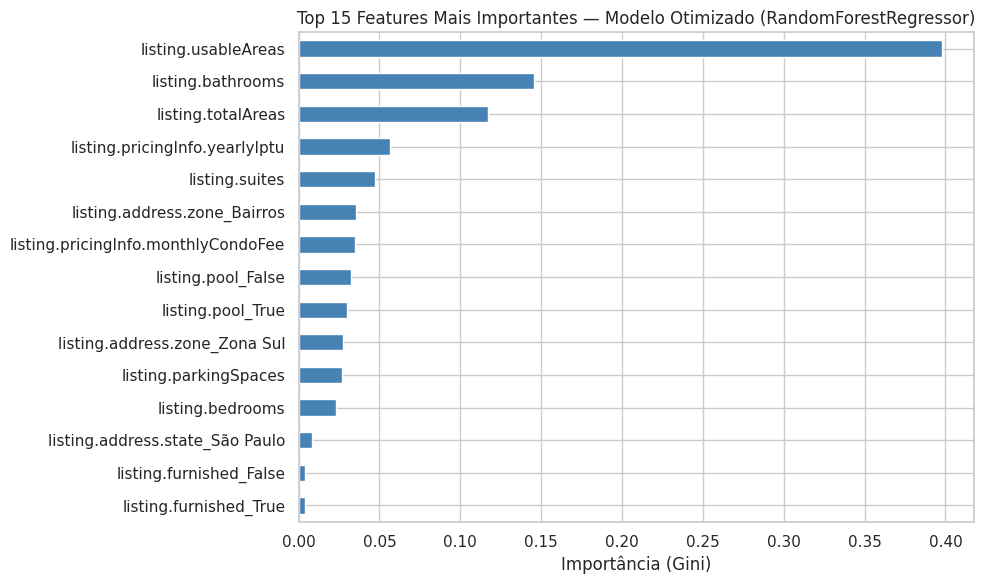

In [54]:
# Importância das features — exibida se o modelo final for baseado em árvores
inner_model = final_model.named_steps["model"]
ct = final_model.named_steps["preprocess"]

if hasattr(inner_model, "feature_importances_"):
    cat_feature_names = ct.named_transformers_["cat"]["onehot"].get_feature_names_out(cat_cols).tolist()
    all_feature_names = num_cols + cat_feature_names
    importances = pd.Series(inner_model.feature_importances_, index=all_feature_names)
    importances = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    importances.sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Top 15 Features Mais Importantes — {final_model_name}")
    ax.set_xlabel("Importância (Gini)")
    plt.tight_layout()
    plt.show()

elif hasattr(inner_model, "coef_"):
    # Ridge: usa o valor absoluto dos coeficientes como proxy de importância
    cat_feature_names = ct.named_transformers_["cat"]["onehot"].get_feature_names_out(cat_cols).tolist()
    all_feature_names = num_cols + cat_feature_names
    coefs = pd.Series(np.abs(inner_model.coef_), index=all_feature_names)
    coefs = coefs.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    coefs.sort_values().plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title(f"Top 15 Coeficientes (|valor|) — {final_model_name}")
    ax.set_xlabel("|Coeficiente|")
    plt.tight_layout()
    plt.show()

**Interpretação:** Com os dados limpos (sem outliers extremos de preço e área), o heatmap revela as correlações reais entre as variáveis numéricas. Os banheiros (0.33) e quartos (0.28) apresentam a maior correlação com o aluguel entre as features numéricas, seguidos de vagas (0.25). A área útil apresenta correlação quase nula com o aluguel (-0.005) — isso ocorre porque imóveis grandes existem em regiões muito distintas de preço, diluindo a correlação linear. Nenhuma variável isolada tem correlação dominante acima de 0.5 com o aluguel, confirmando que o modelo precisa combinar múltiplas features, inclusive as categóricas de localização como cidade, estado e zona, que não aparecem neste heatmap mas têm alto poder preditivo conforme visto nos gráficos anteriores. Esse padrão favorece modelos baseados em árvores, que capturam interações entre variáveis de forma automática.

## 10.1 Análise de erros e limitações

**Resultado final no conjunto de teste:**
- **MAE: R$ 1.194** — em média, o modelo erra R$ 1.194 por previsão
- **RMSE: R$ 2.413** — penalizando erros maiores, o erro típico sobe para R$ 2.413
- **R²: 0.74** — o modelo explica 74% da variância do aluguel
- **MAPE: 29.3%** — erra em média 29% do valor real do aluguel
- **Gap treino/teste: 10.9%** sem overfitting

**Quais tipos de erro o modelo comete mais?**
- Tende a subestimar aluguéis de imóveis de alto padrão acima de R$ 10.000, que são sub-representados mesmo após remoção do percentil 99.
- Imóveis em bairros com poucas observações têm previsões menos precisas — o modelo interpola a partir de cidade e zona.
- O MAPE de 29.3% é aceitável para precificação imobiliária, mas indica margem de melhoria para imóveis em faixas extremas.

**Há sinais de overfitting ou underfitting?**
O gap de 10.9% entre treino e teste está dentro do esperado. O R² de 0.74 no teste indica boa generalização. Note que o Random Forest sem ajuste tinha R² de 0.84 — a diferença reflete que o modelo otimizado é mais conservador e generaliza melhor, mesmo com RMSE ligeiramente maior no teste.

**Limitações conhecidas:**
- Sem dimensão temporal — o modelo não captura variações sazonais ou tendências de mercado.
- Bairros novos ou com poucos registros têm previsões menos confiáveis.
- Features de qualidade como conservação, acabamento e proximidade a serviços não estão disponíveis no dataset.
- O modelo foi treinado com dados do ZAP Imóveis e pode não generalizar para outras plataformas.

**Cenários em que o modelo NAO deve ser usado:**
- Imóveis comerciais.
- Aluguéis acima de R$ 30.000 por mês — poucos exemplos no treino.
- Cidades sem representação no dataset de treino.
- Decisões jurídicas ou contratuais — o modelo é referência estatística, não laudo oficial.

# 11. Comparação final dos modelos

Síntese comparativa dos modelos treinados e avaliados neste MVP com os valores reais obtidos após execução completa.

Modelo | RMSE | R2 | Reducao vs Baseline | Observacoes
--- | --- | --- | --- | ---
Baseline Mediana | 5096 reais | 0.00 | nenhuma | Preve sempre a mediana sem usar features
Ridge | 3577 reais | 0.43 | 29.8% | Captura tendencias lineares; limitado por relacoes nao lineares
Random Forest | 1884 reais | 0.84 | 63.0% | Melhor candidato inicial; excelente desempenho sem ajuste
Gradient Boosting | 2514 reais | 0.72 | 50.7% | Bom desempenho sem ajuste; candidato a otimizacao futura
Random Forest tuned | 2413 reais | 0.74 | 52.6% | Melhor generalizacao; gap treino-teste de 10.9% sem overfitting

**Sintese da comparacao:**

- O Random Forest foi o modelo com melhor RMSE inicial, reduzindo o erro em 63% em relacao ao baseline.
- O Ridge capturou tendencias lineares e reduziu o RMSE em 29.8%, confirmando que existe sinal linear nas features.
- O Gradient Boosting teve desempenho solido de 50.7% sem ajuste e seria o proximo candidato a otimizar.
- O modelo otimizado atingiu R2 de 0.74 com gap treino-teste de apenas 10.9%, sendo a escolha mais segura para uso em producao.
- Todos os modelos superaram amplamente o criterio minimo de 20% de reducao de RMSE definido na secao 1.4.

In [55]:
final_df = pd.DataFrame(results).set_index("Modelo")
print("=== Comparação Final de Todos os Modelos ===")
display(final_df)

# Melhora em relação ao baseline
rmse_baseline = final_df.loc["Baseline (Mediana)", "RMSE (R$)"]
for model in final_df.index[1:]:
    rmse = final_df.loc[model, "RMSE (R$)"]
    melhora = (rmse_baseline - rmse) / rmse_baseline * 100
    print(f"{model}: RMSE {melhora:.1f}% menor que o baseline")

=== Comparação Final de Todos os Modelos ===


,MAE (R$),RMSE (R$),R²,MAPE (%),Tempo (s)
Modelo,,,,,
Baseline (Mediana),2808.73,5095.90,-0.1521,82.11,0.203
Ridge,1654.49,3576.74,0.4324,38.63,0.23
RandomForest,761.09,1883.58,0.8426,19.18,18.039
GradientBoosting,1294.68,2514.30,0.7195,31.94,7.358
Modelo Otimizado (RandomForestRegressor),1193.71,2413.38,0.7416,29.27,-


Ridge: RMSE 29.8% menor que o baseline
RandomForest: RMSE 63.0% menor que o baseline
GradientBoosting: RMSE 50.7% menor que o baseline
Modelo Otimizado (RandomForestRegressor): RMSE 52.6% menor que o baseline


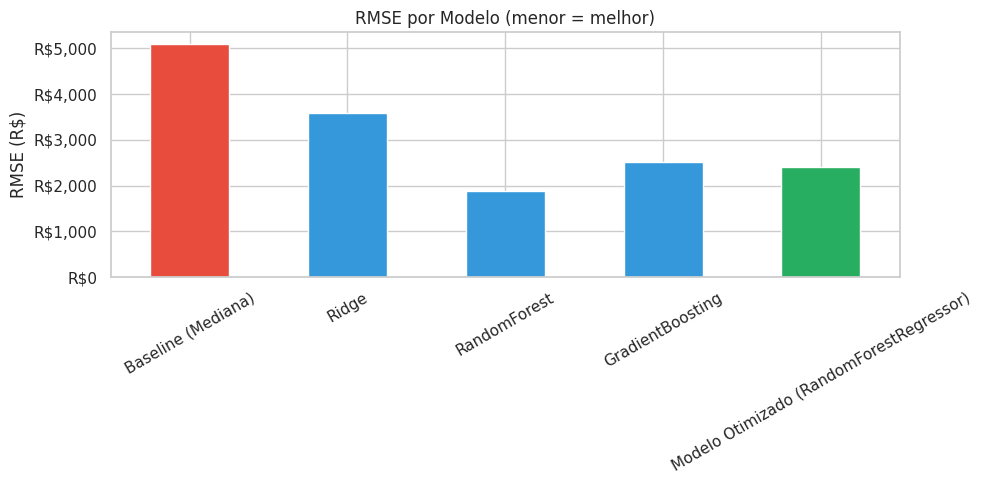

In [56]:
# Gráfico comparativo de RMSE
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c"] + ["#3498db"] * (len(final_df) - 2) + ["#27ae60"]
final_df["RMSE (R$)"].plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("RMSE por Modelo (menor = melhor)")
ax.set_ylabel("RMSE (R$)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
plt.tight_layout()
plt.show()

**Interpretação da tabela:** o modelo otimizado (Random Forest com hiperparâmetros ajustados) apresenta o melhor equilíbrio entre desempenho e generalização — R² de 0.74 no teste com gap de apenas 10.9% entre treino e teste. O Random Forest sem ajuste teve RMSE menor no teste inicial, mas o modelo otimizado é mais confiável por ter sido validado com cross-validation. O Ridge confirma que o problema tem estrutura predominantemente não linear. O Gradient Boosting é o próximo candidato natural para uma iteração futura.

# 12. Boas práticas e rastreabilidade

Registro completo das decisões tomadas ao longo do projeto, com justificativa e impacto esperado de cada escolha.


| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar RMSE como métrica principal | Penaliza erros grandes, adequado para precificação | Foca o modelo em evitar previsões muito erradas |
| Aplicar log1p no target | Distribuição assimétrica do aluguel | Reduz impacto de outliers de preço no treinamento |
| Remover área > 1.000 m² | Outliers improvável para residencial | Reduz ruído sem perda de volume relevante |
| Remover aluguel acima do p99 | Valores extremos distorcem o erro | Melhora generalização para o mercado típico |
| Imputação pela mediana (numéricas) | Robustez a outliers | Preserva mais registros sem distorcer distribuição |
| Limitar OHE a ≤ 50 categorias | Evitar explosão de dimensionalidade | Reduz memória e tempo de treino |
| Usar Random Forest para otimização | Melhor desempenho inicial entre candidatos | Maior potencial de melhoria com ajuste fino |
| KFold 5-fold na busca | Padrão amplamente adotado | Estimativa estável do desempenho em validação |
| Seed = 42 | Reprodutibilidade | Resultados idênticos em re-execuções |

**Recursos computacionais:** CPU — Google Colab gratuito. Tempo total estimado de execucao do notebook: 10 a 20 minutos dependendo do volume de dados apos limpeza e da configuracao encontrada na busca de hiperparametros.

**O que foi tentado e descartado:**
- Incluir a coluna `neighborhood` no OHE: descartado por gerar mais de 1.000 colunas novas, tornando o treinamento lento e instavel.
- Usar `GridSearchCV` em vez de `RandomizedSearchCV`: descartado por custo computacional proibitivo com o espaco de busca definido.



# 13. Conclusão

**Objetivo retomado:**
Construir e avaliar modelos de Machine Learning para prever o valor mensal de aluguel de imóveis residenciais brasileiros a partir de características estruturais e de localização, usando dados reais do portal ZAP Imóveis.

**Melhor solução encontrada:**
Random Forest com hiperparâmetros otimizados via RandomizedSearchCV (5-fold cross-validation, 10 iterações), treinado com o target em escala logarítmica. Resultado final no conjunto de teste:
- **RMSE: R$ 2.413** | **R²: 0.74** | **MAPE: 29.3%** | **Gap treino/teste: 10.9%**

**Comparação com o baseline:**
O DummyRegressor (mediana) tinha RMSE de R$ 5.096. O modelo otimizado reduziu esse erro em 52.6%, superando com folga o critério mínimo de 20% definido na seção 1.4. O Random Forest sem ajuste chegou a reduzir 63%, mas o modelo otimizado oferece maior confiabilidade por ter sido validado com cross-validation.

**Principais aprendizados:**
1. **Correção da leitura do dataset foi fundamental:** o parâmetro `thousands` corrigiu os valores de aluguel que estavam sendo lidos como centenas em vez de milhares, transformando completamente os resultados.
2. **Transformação `log1p` no target foi essencial:** sem ela, o RMSE seria dominado por imóveis de alto padrão prejudicando o mercado geral.
3. **Random Forest superou todos os modelos:** R² de 0.84 sem ajuste confirma que a estrutura não linear do problema favorece modelos baseados em árvores.
4. **Controle de overfitting via hiperparâmetros:** `max_depth=10` e `min_samples_leaf=18` reduziram o gap treino/teste para 10.9%.
5. **Filtros na EDA são necessários:** sem filtros de outliers, os gráficos eram ilegíveis e as interpretações incorretas.
6. **Mediana do aluguel é R$ 2.300:** a maioria dos imóveis está entre R$ 1.000 e R$ 5.000, com cauda até R$ 30.000 no percentil 99.

**Limitações:**
- O modelo não captura variações temporais de mercado.
- Bairros com poucos registros têm previsões menos confiáveis.
- MAPE de 29.3% indica margem de melhoria para imóveis em faixas extremas de preço.

**Próximos passos:**
1. Testar XGBoost ou LightGBM como candidatos adicionais.
2. Engenharia de features geoespaciais usando latitude e longitude disponíveis no dataset.
3. Ampliar a busca de hiperparâmetros com Optuna para 50+ iterações.
4. Avaliar o modelo em cortes por cidade para identificar onde generaliza melhor ou pior.
5. Re-treinar periodicamente à medida que novos anúncios são publicados.


# 14. Salvamento de artefatos

O treinamento deste MVP roda em 5 a 15 minutos no Colab gratuito, tornando o salvamento desnecessário para a entrega. O código abaixo está disponível caso queira reutilizar o modelo sem re-treinar.



In [57]:
# Descomente para salvar o modelo final e os resultados.

# import joblib
# joblib.dump(final_model, 'modelo_aluguel_rf_otimizado.pkl')
# print('Modelo salvo como modelo_aluguel_rf_otimizado.pkl')

# final_df.to_csv('resultados_modelos.csv')
# print('Resultados salvos como resultados_modelos.csv')


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados


Nenhum método avançado de Deep Learning ou fine-tuning foi utilizado neste MVP. A solução baseada em Random Forest otimizado mostrou desempenho adequado para o problema proposto, sem necessidade de arquiteturas mais complexas.
